# 딥러닝 라이브러리 2가지
## tensorflow(google)- 산업용
* 이미지 관련 라이브러리
* keras를 이용해 코딩이 쉬움
* 순차적, 함수적, 클래스

## pytorch(meta)- 연구용
* 자연어 관련 라이브러리
* 허깅페이스, 랭체인
* 클래스 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

In [2]:
data=pd.read_csv("https://raw.githubusercontent.com/haram4th/ablearn/main/Taitanic_train.csv")

In [3]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
data=data[['Survived', 'Pclass','Sex', 'Age', 'SibSp',
       'Parch','Embarked']]

In [6]:
data.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Embarked
0,0,3,male,22.0,1,0,S
1,1,1,female,38.0,1,0,C
2,1,3,female,26.0,0,0,S
3,1,1,female,35.0,1,0,S
4,0,3,male,35.0,0,0,S


In [7]:
data['family']=data["SibSp"]+data['Parch']

In [8]:
data['Age'] = data['Age'].fillna(data['Age'].mean())
# data.loc[: ,'Age']=data['Age'].fillna(data['Age'].mean())

In [9]:
data['Embarked']=data['Embarked'].fillna(data['Embarked'].mode()[0])

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Embarked  891 non-null    object 
 7   family    891 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 55.8+ KB


In [11]:
data=data.drop(['SibSp','Parch'], axis=1)
data

,Survived,Pclass,Sex,Age,Embarked,family
0,0,3,male,22.000000,S,1
1,1,1,female,38.000000,C,1
2,1,3,female,26.000000,S,0
3,1,1,female,35.000000,S,1
4,0,3,male,35.000000,S,0
...,...,...,...,...,...,...
886,0,2,male,27.000000,S,0
887,1,1,female,19.000000,S,0
888,0,3,female,29.699118,S,3
889,1,1,male,26.000000,C,0


In [12]:
data=pd.get_dummies(data, drop_first=True)

In [13]:
X=data.drop('Survived', axis=1)
y=data['Survived']

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

# 딥러닝시에도 데이터의 스케일을 맞춰 주는 것이 좋다.
* standardscaler를 주로 사용. 이상값이 많을 경우 robustscaler 사용
* 이진분류(0,1): MinMaxScaler
* 연속값 예측: standardscaler

In [16]:
from sklearn.preprocessing import MinMaxScaler

In [17]:
mms=MinMaxScaler()
mms_X_train=mms.fit_transform(X_train)
mms_X_test=mms.transform(X_test)
mms_X_train=pd.DataFrame(mms_X_train, columns=X_train.columns, index=X_train.index)
mms_X_test=pd.DataFrame(mms_X_test, columns=X_test.columns, index=X_test.index)

In [18]:
display(mms_X_test)

,Pclass,Age,family,Sex_male,Embarked_Q,Embarked_S
625,0.0,0.761247,0.0,1.0,0.0,1.0
566,1.0,0.233476,0.0,1.0,0.0,1.0
459,1.0,0.367921,0.0,1.0,1.0,0.0
804,1.0,0.334004,0.0,1.0,0.0,1.0
338,1.0,0.560191,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...
184,1.0,0.044986,0.2,0.0,0.0,1.0
607,0.0,0.334004,0.0,1.0,0.0,1.0
624,1.0,0.258608,0.0,1.0,0.0,1.0
103,1.0,0.409399,0.0,1.0,0.0,1.0


In [19]:
display(mms_X_train)

,Pclass,Age,family,Sex_male,Embarked_Q,Embarked_S
748,0.0,0.233476,0.1,1.0,0.0,1.0
45,1.0,0.367921,0.0,1.0,0.0,1.0
28,1.0,0.367921,0.0,0.0,1.0,0.0
633,0.0,0.367921,0.0,1.0,0.0,1.0
403,1.0,0.346569,0.1,1.0,0.0,1.0
...,...,...,...,...,...,...
476,0.5,0.421965,0.1,1.0,0.0,1.0
190,0.5,0.396833,0.0,0.0,0.0,1.0
736,1.0,0.597889,0.4,0.0,0.0,1.0
462,0.0,0.585323,0.0,1.0,0.0,1.0


# Tensorflow Sequential API를 사용한 순차적 모델 생성 및 분석

* Sequential: 인공신경망을 순차적으로 작성할 때 사용
* Dense: 층,레이어
* 1. 신경망 모델 정의
* 2. 신경망 모델 훈련
* 3. 훈련된 모델로 테스트
* 4. 검증

In [20]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

2025-05-15 09:22:57.280890: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-15 09:22:57.331270: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747268577.380407   13869 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747268577.397914   13869 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747268577.435051   13869 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

* 입력층은 반드시 독립변수의수(input_dim)를 정확히 지정
* 신경망 모델의 은닉층은 2~3개 정도로 한다.
* Dense의 노드수는 2의 배수의 지정 2 4 8 16 256
* Dense의 노드는 큰 수에서 작은 수로 줄여나간다.
* 은닉층의 활성화 함수: Reru
* 출력층은 이진분류일 경우 sigmoid, 다중분류일 경우 softmax
* 회귀분석일 경우(종속변수가 연속형(수치)인 경우) 활성화 함수 없이 노드를 1로 지정드를 1로 지정

In [21]:
mms_X_train.shape[1]

6

In [22]:
# 신경망 모델 직접 정의(keras 3.0, tensorflow 2.19 기준): decision tree는 이미 만들어져 있음
model= Sequential()
model.add(Input(shape=(mms_X_train.shape[1],))) #입력층
model.add(Dense(64, activation='relu')) # 은닉층
model.add(Dense(32, activation='relu')) # 은닉층
model.add(Dense(16, activation='relu')) # 은닉층
model.add(Dense(1, activation='sigmoid')) # 출력층, 이진분류이므로 sigmpoid 

I0000 00:00:1747268586.548467   13869 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 1347 MB memory:  -> device: 0, name: NVIDIA GeForce MX450, pci bus id: 0000:01:00.0, compute capability: 7.5


# 모델의 파라미터 세팅 model.compile()
* loss: 오차 계산 지표
    * 이진분류: binary_crossentropy
    * 다중분류: categorical_crossentropy - y가 one-hot encoding
    * 데이터에 0이 많은 희소행렬인 경우: sparse_categorical_crossentropy- y가 label encoding
    * 연속형 데이터(회귀분석): mse
* optimizer: learning_rate
    * adam을 가장 많이 사용
* metrics: 평가지표 accuracy

In [23]:
# 모델의 파라미터 세팅
model.compile(loss='binary_crossentropy',optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

# 모델 훈련 model.fit(X_train, y_train)
* epochs: 전체 데이터를 한 번 훈련하는 주기 10-100 사이
* batch_size: 전체 데이터를 쪼개서 훈련, 데이터의 묶음, 메모리에 맞춰서 크기 조절(2의 배수) 32, 64로 쪼개서 넣는 것 추천
* validation_data: 검증 데이터로 모델 검증 실시

In [24]:
history=model.fit(mms_X_train, y_train, epochs=100, batch_size=32, 
                  validation_data=(mms_X_test, y_test))

Epoch 1/100


I0000 00:00:1747268589.927202   13918 service.cc:152] XLA service 0x7eff8001d600 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747268589.927344   13918 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce MX450, Compute Capability 7.5
2025-05-15 09:23:09.998253: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747268590.549519   13918 cuda_dnn.cc:529] Loaded cuDNN version 90300


16/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5201 - loss: 0.6771

I0000 00:00:1747268593.058009   13918 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 277ms/step - accuracy: 0.5390 - loss: 0.6695 - val_accuracy: 0.6231 - val_loss: 0.6110
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6224 - loss: 0.6102 - val_accuracy: 0.7127 - val_loss: 0.5659
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7099 - loss: 0.5585 - val_accuracy: 0.7799 - val_loss: 0.5288
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7904 - loss: 0.5173 - val_accuracy: 0.7687 - val_loss: 0.5053
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7693 - loss: 0.4839 - val_accuracy: 0.7724 - val_loss: 0.4842
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.7842 - loss: 0.4673 - val_accuracy: 0.7761 - val_loss: 0.4721
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.7903 - loss: 0.4411 - val_accuracy: 0.7836 - val_loss: 0.4608
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.7996 - loss: 0.4500 - val_accuracy: 0.7724 - val

# 딥러닝 모델 성능 평가
* 딥러닝에서 모델의 성능을 평가하는 지표는 loss
* 보통 loss가 낮으면 accuracy가 올라가지만 비례하지 않을 때도 있음
* accuracy와 loss간 차이가 있을 때, 

In [25]:
score=model.evaluate(mms_X_test, y_test)
print('test loss', score[0])
print('test accuracy', score[1])

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8221 - loss: 0.4294
test loss 0.44316771626472473
test accuracy 0.8097015023231506


In [29]:
for i in history.history:
    print(f"{i}:history.history[i]')

SyntaxError: EOL while scanning string literal (1258046534.py, line 2)

# 훈련 결과 시각화하기 history.history['loss'], history.history['val_loss']

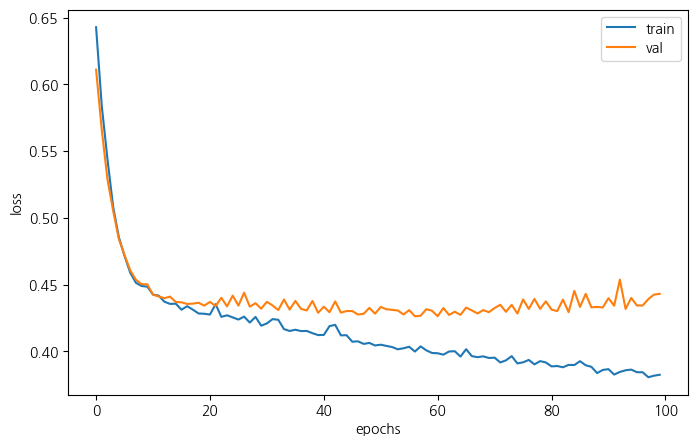

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

# 모델의 예측 값 출력

In [33]:
pred=model.predict(mms_X_test)
pred

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


array([[0.2521624 ],
       [0.15158588],
       [0.11153147],
       [0.11077499],
       [0.07324646],
       [0.34979573],
       [0.10951946],
       [0.8231807 ],
       [0.1044982 ],
       [0.9483028 ],
       [0.74073416],
       [0.99656326],
       [0.36685047],
       [0.24946602],
       [0.82985085],
       [0.7621925 ],
       [0.11153147],
       [0.36150607],
       [0.9111365 ],
       [0.34092778],
       [0.0763941 ],
       [0.09332813],
       [0.4737872 ],
       [0.11077499],
       [0.16263516],
       [0.13847284],
       [0.97299147],
       [0.29439753],
       [0.18738244],
       [0.25724   ],
       [0.8798192 ],
       [0.9442575 ],
       [0.11153147],
       [0.7685502 ],
       [0.98969054],
       [0.47479522],
       [0.11153147],
       [0.06964575],
       [0.11153147],
       [0.3195146 ],
       [0.10951946],
       [0.8856014 ],
       [0.51232105],
       [0.9889587 ],
       [0.9856283 ],
       [0.13739891],
       [0.4396689 ],
       [0.195

In [34]:
result=pd.DataFrame(dict(y_test=y_test, pred=pred[:,0]))
result

,y_test,pred
625,0,0.252162
566,0,0.151586
459,0,0.111531
804,1,0.110775
338,1,0.073246
...,...,...
184,1,0.747173
607,1,0.344056
624,0,0.131232
103,0,0.097789


In [35]:
result['pred']=result['pred'].apply(lambda x: 1 if x>=0.5 else 0)
result

,y_test,pred
625,0,0
566,0,0
459,0,0
804,1,0
338,1,0
...,...,...
184,1,1
607,1,0
624,0,0
103,0,0


In [36]:
from sklearn.metrics import classification_report
print(classification_report(result['y_test'], result['pred']))

              precision    recall  f1-score   support

           0       0.81      0.90      0.85       165
           1       0.80      0.67      0.73       103

    accuracy                           0.81       268
   macro avg       0.81      0.78      0.79       268
weighted avg       0.81      0.81      0.81       268



In [37]:
from sklearn.tree import DecisionTreeClassifier

In [40]:
dtc=DecisionTreeClassifier()
dtc.fit(mms_X_train, y_train)
pred2=dtc.predict(mms_X_test)
print(classification_report(y_test, pred2))

              precision    recall  f1-score   support

           0       0.78      0.84      0.81       165
           1       0.71      0.63      0.67       103

    accuracy                           0.76       268
   macro avg       0.75      0.73      0.74       268
weighted avg       0.75      0.76      0.75       268



# Functional API를 이용한 함수형 모델
* Sequential API는 단순히 층을 여러 개 쌓는 형태라 복잡한 모델 생성에 한계가 있음
* Functional API는 입력층과 출력층을 사용자가 직접 정의 가능
* 다중입력(Multi-input), 다중출력(Multi-output)등 복잡한 모델을 정의 할 수 있음.
* Input(shape=(독립변수 수))로 입력층 정의
* 이전 층을 다음 층의 입력으로 사용
* model의 입력과 출력을 정의

In [41]:
# tensorflow 2.19 버전용
from keras.layers import Input, Dense
from keras.models import Model

In [42]:
# 입력층
inputs=Input(shape=(mms_X_train.shape[1],))

# 은닉층
x=Dense(64, activation='relu')(inputs)
x=Dense(32, activation='relu')(x)
x=Dense(16, activation='relu')(x)

# 출력층
outputs=Dense(1, activation='sigmoid')(x)

#모델 정의
model=Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,073 (12.00 KB)

 Trainable params: 3,073 (12.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.6152 - loss: 0.6705 - val_accuracy: 0.6157 - val_loss: 0.6156
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6122 - loss: 0.6019 - val_accuracy: 0.6343 - val_loss: 0.5791
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6974 - loss: 0.5551 - val_accuracy: 0.8134 - val_loss: 0.5453
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ -0s -23454us/step - accuracy: 0.7792 - loss: 0.5309 - val_accuracy: 0.7761 - val_loss: 0.5228
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7985 - loss: 0.4998 - val_accuracy: 0.7761 - val_loss: 0.5032
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7890 - loss: 0.5007 - val_accuracy: 0.7761 - val_loss: 0.4859
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7902 - loss: 0.4678 - val_accuracy: 0.7761 - val_loss: 0.4758
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7909 - loss: 0.4645 - val_accuracy: 0.

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
              precision    recall  f1-score   support

           0       0.81      0.86      0.83       165
           1       0.75      0.67      0.71       103

    accuracy                           0.79       268
   macro avg       0.78      0.77      0.77       268
weighted avg       0.78      0.79      0.78       268



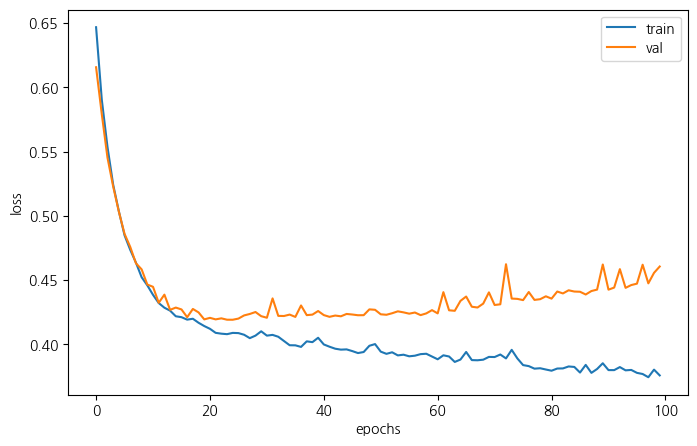

In [43]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history=model.fit(mms_X_train, y_train, epochs=100, 
                  batch_size=32, validation_data=(mms_X_test, y_test))
pred=model.predict(mms_X_test)
pred=pd.DataFrame(pred)
pred=pred[0].apply(lambda x: 1 if x>0.5 else 0)
print(classification_report(y_test,pred))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train','val'])
plt.show()

# class형으로 만들기 (Model Subclass API)
* class 형태의 모델 정의 방법
* keras의 Model을 상속받아 작성

In [44]:
class Titanic(Model):
    def __init__(self):
        super(Titanic, self).__init__()
        self.dense1=Dense(128, activation='relu')
        self.dense2=Dense(64, activation='relu')
        self.dense3=Dense(32, activation='relu')
        self.dense4=Dense(16, activation='relu')
        self.classifier=Dense(1, activation='sigmoid')
        
    def call(self, inputs):
        x=self.dense1(inputs)
        x=self.dense2(x)
        x=self.dense3(x)
        x=self.dense4(x)
        return self.classifier(x)

In [45]:
model=Titanic()
print(model.summary())

Model: "titanic"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [46]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history=model.fit(mms_X_train, y_train, epochs=100, batch_size=32)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.5959 - loss: 0.6873
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8087 - loss: 0.5778
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8016 - loss: 0.4928
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7874 - loss: 0.4407
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7897 - loss: 0.4691
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7809 - loss: 0.4688
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8011 - loss: 0.4376
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8272 - loss: 0.4107
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8086 - loss: 0.4650
Epoch 10/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8096 - loss: 0.4157
Epoch 11/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8046 - loss: 0.4670
Epoch 12/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy